In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

INPUT_SIZE = 28 * 28 
NUM_CLASSES = 10
BATCH_SIZE = 500 
EPOCHS = 5         
SEED = 42          

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../data', train=True, transform=transform, download=False)
test_dataset = datasets.MNIST(root='../data', train=False, transform=transform, download=False)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

## SGD

In [2]:
# --- Loss Function ---
criterion = nn.CrossEntropyLoss() 
all_loss_histories = {}

# --- Learning Rates ---
LEARNING_RATES = [0.5, 0.3, 0.1, 0.05, 0.03, 0.01]

for lr in LEARNING_RATES:
    print(f"--- Starting Training for Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            output = model(data)
            loss = criterion(output, target)
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    # Update loss history
    all_loss_histories[lr] = loss_history

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

import json
with open("results/lce_sgd.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for Learning Rate: 0.5 ---
LR: 0.5, Epoch [1/5], Final Batch Loss: 0.43778
LR: 0.5, Epoch [2/5], Final Batch Loss: 1.05968
LR: 0.5, Epoch [3/5], Final Batch Loss: 0.30559
LR: 0.5, Epoch [4/5], Final Batch Loss: 0.29996
LR: 0.5, Epoch [5/5], Final Batch Loss: 0.98768
Final Accuracy for LR 0.5: 90.49%

--- Starting Training for Learning Rate: 0.3 ---
LR: 0.3, Epoch [1/5], Final Batch Loss: 0.37455
LR: 0.3, Epoch [2/5], Final Batch Loss: 0.43427
LR: 0.3, Epoch [3/5], Final Batch Loss: 0.25786
LR: 0.3, Epoch [4/5], Final Batch Loss: 0.25258
LR: 0.3, Epoch [5/5], Final Batch Loss: 0.45054
Final Accuracy for LR 0.3: 90.87%

--- Starting Training for Learning Rate: 0.1 ---
LR: 0.1, Epoch [1/5], Final Batch Loss: 0.35321
LR: 0.1, Epoch [2/5], Final Batch Loss: 0.28168
LR: 0.1, Epoch [3/5], Final Batch Loss: 0.24737
LR: 0.1, Epoch [4/5], Final Batch Loss: 0.25600
LR: 0.1, Epoch [5/5], Final Batch Loss: 0.21478
Final Accuracy for LR 0.1: 92.05%

--- Starting Training for Le

## ADAM

In [3]:
LEARNING_RATES = [0.05, 0.01, 0.005, 0.001, 0.0005]
criterion = nn.CrossEntropyLoss() 
all_loss_histories = {}

for lr in LEARNING_RATES:
    print(f"--- Starting Training for Adam with Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            output = model(data)
            loss = criterion(output, target)
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[lr] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

import json
with open("results/lce_adam.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for Adam with Learning Rate: 0.05 ---
LR: 0.05, Epoch [1/5], Final Batch Loss: 0.57175
LR: 0.05, Epoch [2/5], Final Batch Loss: 0.57260
LR: 0.05, Epoch [3/5], Final Batch Loss: 0.44272
LR: 0.05, Epoch [4/5], Final Batch Loss: 0.68330
LR: 0.05, Epoch [5/5], Final Batch Loss: 0.49365
Final Accuracy for LR 0.05: 88.51%

--- Starting Training for Adam with Learning Rate: 0.01 ---
LR: 0.01, Epoch [1/5], Final Batch Loss: 0.30413
LR: 0.01, Epoch [2/5], Final Batch Loss: 0.26148
LR: 0.01, Epoch [3/5], Final Batch Loss: 0.22538
LR: 0.01, Epoch [4/5], Final Batch Loss: 0.24626
LR: 0.01, Epoch [5/5], Final Batch Loss: 0.24631
Final Accuracy for LR 0.01: 91.06%

--- Starting Training for Adam with Learning Rate: 0.005 ---
LR: 0.005, Epoch [1/5], Final Batch Loss: 0.33000
LR: 0.005, Epoch [2/5], Final Batch Loss: 0.25186
LR: 0.005, Epoch [3/5], Final Batch Loss: 0.21791
LR: 0.005, Epoch [4/5], Final Batch Loss: 0.24423
LR: 0.005, Epoch [5/5], Final Batch Loss: 0.22854
Final A

## Default OLNM

In [3]:
import sys, os
sys.path.append(os.path.abspath('..'))
from olnm import OLNM


In [10]:
# LEARNING_RATES = [0.3, 0.1, 0.05, 0.01, 0.005]
LEARNING_RATES = [1.0, 0.5, 0.1, 0.05, 0.01, 0.005]
criterion = nn.CrossEntropyLoss() 
all_loss_histories = {}

for lr in LEARNING_RATES:
    print(f"--- Starting Training for OLNM with Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = OLNM(model.parameters(), 
                              lr=lr, 
                              T=50, 
                              batch_size=BATCH_SIZE,
                              )

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            def closure(grad=True):
                output = model(data)
                loss = criterion(output, target)
                if grad:
                    optimizer.zero_grad()
                    loss.backward()
                return loss

            loss = optimizer.step(closure)

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[lr] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

import json
with open("results/lce_olnm.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for OLNM with Learning Rate: 1.0 ---
LR: 1.0, Epoch [1/5], Final Batch Loss: 1.82151
LR: 1.0, Epoch [2/5], Final Batch Loss: 2.56245
LR: 1.0, Epoch [3/5], Final Batch Loss: 0.92168
LR: 1.0, Epoch [4/5], Final Batch Loss: 0.96503
LR: 1.0, Epoch [5/5], Final Batch Loss: 1.44486
Final Accuracy for LR 1.0: 89.44%

--- Starting Training for OLNM with Learning Rate: 0.5 ---
LR: 0.5, Epoch [1/5], Final Batch Loss: 0.78140
LR: 0.5, Epoch [2/5], Final Batch Loss: 0.92558
LR: 0.5, Epoch [3/5], Final Batch Loss: 0.62239
LR: 0.5, Epoch [4/5], Final Batch Loss: 0.69817
LR: 0.5, Epoch [5/5], Final Batch Loss: 0.62402
Final Accuracy for LR 0.5: 89.87%

--- Starting Training for OLNM with Learning Rate: 0.1 ---
LR: 0.1, Epoch [1/5], Final Batch Loss: 0.31759
LR: 0.1, Epoch [2/5], Final Batch Loss: 0.26246
LR: 0.1, Epoch [3/5], Final Batch Loss: 0.21440
LR: 0.1, Epoch [4/5], Final Batch Loss: 0.24452
LR: 0.1, Epoch [5/5], Final Batch Loss: 0.22708
Final Accuracy for LR 0.1: 91.95%

## Visualization

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("results/lce_olnm.json", "r") as f:
    olnm_histories = json.load(f)
with open("results/lce_sgd.json", "r") as f:
    sgd_histories = json.load(f)
with open("results/lce_adam.json", "r") as f:
    adam_histories = json.load(f)

In [18]:
# --- Plotting ---
def plot_histories(histories, title, filename):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 6))
    for lr, history in histories.items():
        window_size = 10
        smoothed_history = np.convolve(history, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_history, 
                 label=f'{lr}',
                 linewidth=2,
                #  markevery=50, 
                #  marker='*',
                 )
    # plt.title(title, fontsize=16)
    plt.xlabel('Iteration', fontsize=16)
    plt.xticks(fontsize=16)
    plt.ylabel('Cross Entropy Loss', fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title=f'{title} Learning Rate', fontsize=16)
    plt.grid(True, alpha=0.5)
    plt.ylim(0, 1)
    plt.savefig(f"imgs/png/{filename}.png")
    plt.savefig(f"imgs/pdf/{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"imgs/svg/{filename}.svg", bbox_inches='tight')
    plt.show()

### SGD

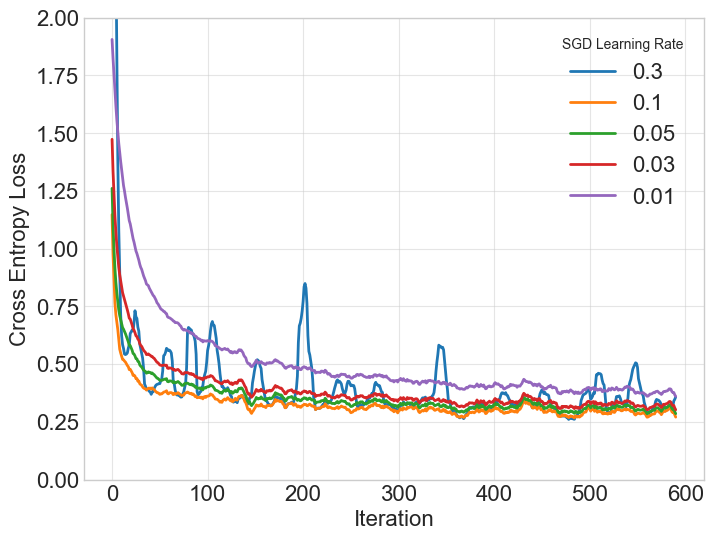

In [6]:
plot_histories(sgd_histories, 'SGD', 'tuning_lce_sgd')

### Adam

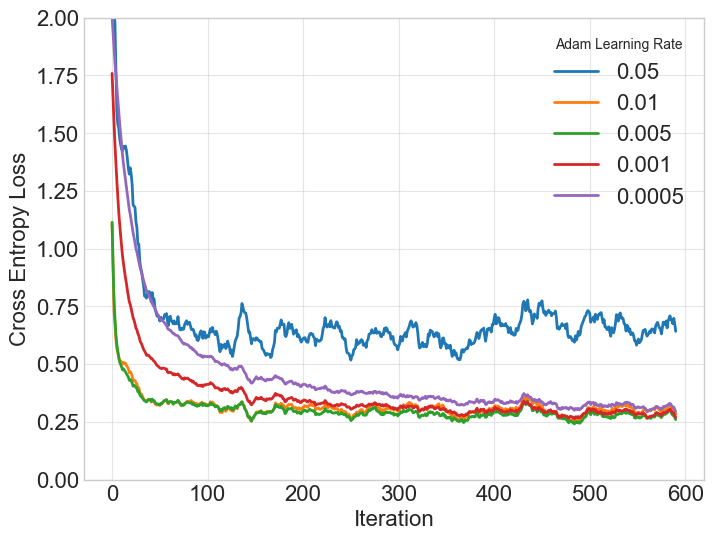

In [7]:
plot_histories(adam_histories, 'Adam', 'tuning_lce_adam')

### OLNM

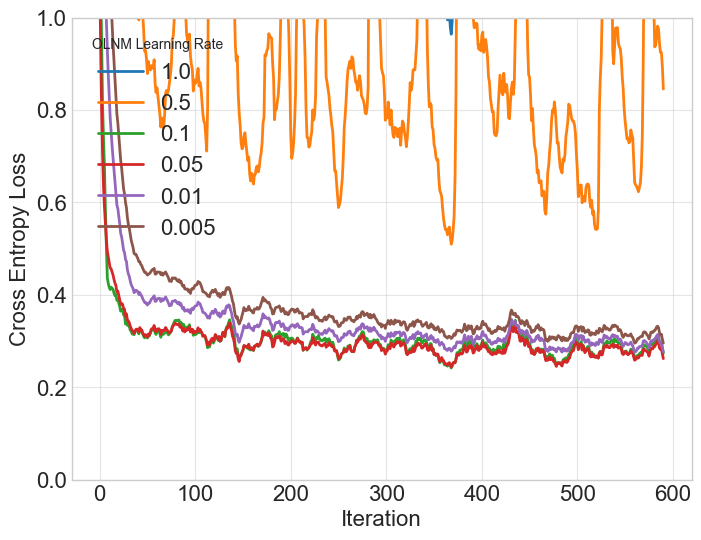

In [19]:
plot_histories(olnm_histories, 'OLNM', 'tuning_lce_olnm')